<a href="https://colab.research.google.com/github/letruc271193-dot/project/blob/main/Dishesproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# ==========================================
# 1. TIỀN XỬ LÝ DỮ LIỆU & TĂNG CƯỜNG ẢNH
# ==========================================
# Thay đổi đường dẫn này trỏ tới thư mục chứa dataset Bài 2 của bạn trên Drive
train_dir = "/content/drive/MyDrive/Dataset_dish"

# Kích thước ảnh và batch_size
img_width, img_height = 200, 200
batch_size = 32

# Sử dụng validation_split để chia ra một tập xác thực (20% dữ liệu) giúp vẽ biểu đồ val_accuracy
train_datagen = ImageDataGenerator(
    rescale=1.0/255, # Chuẩn hóa pixel về [0,1]
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest",
    validation_split=0.2 # Trích 20% dữ liệu để làm tập validation (kiểm tra chéo)
)


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='training'
)


validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode="categorical",
    subset='validation'
)

Found 261 images belonging to 5 classes.
Found 62 images belonging to 5 classes.


In [ ]:
# ==========================================
# 2. XÂY DỰNG MÔ HÌNH CNN
# ==========================================
model = Sequential([
    # Khối 1
    Conv2D(32, (3,3), activation="relu", input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2,2),

    # Khối 2
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    # Khối 3 (Đã nối từ đoạn code bổ sung của bạn)
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    # Chuyển đổi và Phân loại
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5), # Giảm overfitting
    Dense(5, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,157 (33.42 MB)

 Trainable params: 8,761,157 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 105s 11s/step - accuracy: 0.2605 - loss: 2.4149 - val_accuracy: 0.6129 - val_loss: 1.4574
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 468ms/step - accuracy: 0.5326 - loss: 1.2385 - val_accuracy: 0.6290 - val_loss: 0.8896
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 439ms/step - accuracy: 0.6398 - loss: 0.9436 - val_accuracy: 0.5968 - val_loss: 0.8038
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 512ms/step - accuracy: 0.6897 - loss: 0.7781 - val_accuracy: 0.6774 - val_loss: 0.6814
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 652ms/step - accuracy: 0.7548 - loss: 0.6476 - val_accuracy: 0.7581 - val_loss: 0.5307
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 429ms/step - accuracy: 0.7778 - loss: 0.5215 - val_accuracy: 0.7097 - val_loss: 0.6439
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 499ms/step - accuracy: 0.8046 - loss: 0.4470 - val_accuracy: 0.7742 - val_loss: 0.4426
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 557ms/step - accuracy: 0.8238 - loss: 0.4612 - val_accuracy: 0.6935 - v

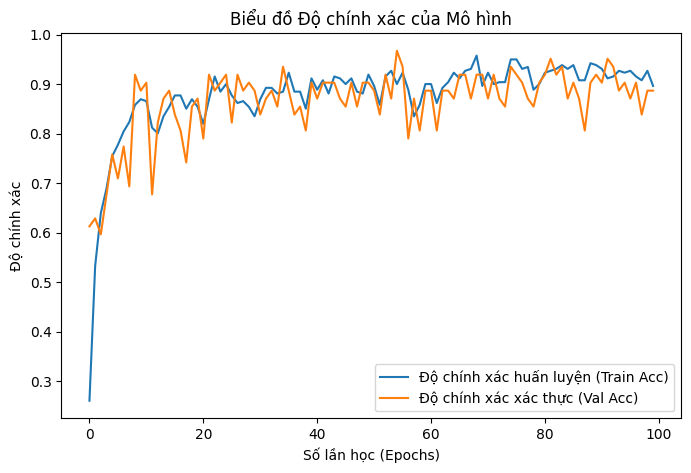

In [ ]:
# Biên dịch mô hình
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# Xem tóm tắt cấu trúc mạng
model.summary()

# ==========================================
# 3. HUẤN LUYỆN MÔ HÌNH
# ==========================================
epochs = 100

# Đưa cả tập train và validation vào để máy học và đánh giá
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=epochs
)

# ==========================================
# 4. ĐÁNH GIÁ KẾT QUẢ BẰNG BIỂU ĐỒ
# ==========================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label="Độ chính xác huấn luyện (Train Acc)")
plt.plot(history.history['val_accuracy'], label="Độ chính xác xác thực (Val Acc)")
plt.title("Biểu đồ Độ chính xác của Mô hình")
plt.xlabel("Số lần học (Epochs)")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

In [ ]:
import pickle

# Lưu mô hình đã huấn luyện
model.save('/content/drive/MyDrive/Dataset_dish/bai2_model.h5')

# Lưu danh sách tên các danh mục (nhãn)
with open('/content/drive/MyDrive/Dataset_dish/bai2_class_labels.pkl', 'wb') as f:
    pickle.dump(train_generator.class_indices, f)

print("Đã huấn luyện xong! Đã lưu mô hình (bai2_model.h5) và nhãn thành công vào Google Drive!")

Đã huấn luyện xong! Đã lưu mô hình (bai2_model.h5) và nhãn thành công vào Google Drive!


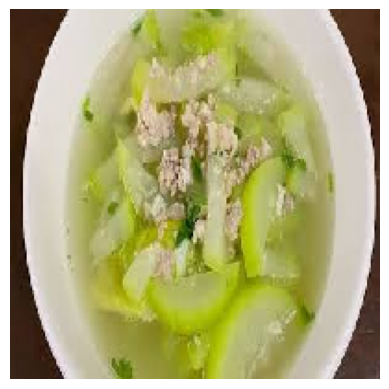

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
Kết quả dự đoán: Canh_bí _đao
Độ tự tin: 100.00%


In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt
import pickle

# 1. Tải lại mô hình và nhãn đã lưu của bài 2
model = load_model('/content/drive/MyDrive/Dataset_dish/bai2_model.h5')

with open('/content/drive/MyDrive/Dataset_dish/bai2_class_labels.pkl', 'rb') as f:
    class_indices = pickle.load(f)

# Đảo ngược dictionary để tra cứu tên từ ID
class_labels = {v: k for k, v in class_indices.items()}

# 2. Xử lý ảnh mới để dự đoán
# Thay bằng đường dẫn bức ảnh bạn muốn test
path = "/content/dish3.jpeg"

# Hiển thị ảnh
img = load_img(path, target_size=(200, 200))
plt.imshow(img)
plt.axis('off')
plt.show()

# Chuyển đổi ảnh thành mảng dữ liệu
img_arr = img_to_array(img)
img_arr = img_arr / 255.0 # Chuẩn hóa giống lúc train
img_arr = np.expand_dims(img_arr, axis=0) # Thêm batch dimension -> (1, 200, 200, 3)

# 3. Tiến hành dự đoán
predictions = model.predict(img_arr)
predicted_class = np.argmax(predictions)
person_name = class_labels[predicted_class]
confidence = np.max(predictions) * 100

print(f"Kết quả dự đoán: {person_name}")
print(f"Độ tự tin: {confidence:.2f}%")